# DQN: PyTorch Wrapper 튜토리얼

이 튜토리얼은 강화학습의 기초인 DQN(Deep Q-Network)을 구현하는 방법을 안내한다. 라이브러리는 최신 표준인 `gymnasium`과 `torch` 최신 버전을 기준으로 작성되었다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다. 코랩(Colab)이나 서버 환경에서는 화면이 없으므로 이를 통해 시각화를 가능하게 한다.

In [13]:
# 최신 파이썬 라이브러리 설치 (gym 대신 gymnasium 사용)
%pip install -q gymnasium[box2d] gymnasium[other] pyvirtualdisplay imageio

E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
# 화면이 없는 서버 환경에서 렌더링을 수행하기 위해 가상 윈도우를 생성한다.
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 `torch`, `gymnasium`, `numpy` 등 핵심 라이브러리를 불러온다. `pytorch_lightning` 의존성을 제거하고 순수 PyTorch를 사용한다.

In [5]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습된 에이전트의 플레이 영상을 주피터 노트북에서 바로 확인할 수 있도록 돕는 함수다.

In [6]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Deep Q-Network 생성 (Create the Deep Q-Network)

상태(State)를 입력받아 각 행동(Action)에 대한 Q값(가치)을 출력하는 신경망을 정의한다.

In [7]:
class DQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        """
        DQN 네트워크 초기화
        :param obs_size: 입력 상태의 차원 (Observation Space)
        :param hidden_size: 은닉층 노드 수
        :param n_actions: 출력 행동의 수 (Action Space)
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        """
        순전파(Forward) 연산
        :param x: 입력 상태 텐서
        :return: 각 행동별 Q-Value
        """
        return self.net(x.float())

### 5. 경험 리플레이 버퍼 (Replay Buffer)

에이전트가 환경과 상호작용하며 얻은 경험(상태, 행동, 보상, 다음 상태, 종료 여부)을 저장하고, 학습 시 무작위로 샘플링하여 데이터 간의 상관관계를 끊어주는 역할을 한다.

In [8]:
class ReplayBuffer:
    def __init__(self, capacity):
        """
        리플레이 버퍼 초기화
        :param capacity: 버퍼의 최대 크기
        """
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        """
        새로운 경험을 버퍼에 추가한다.
        """
        self.buffer.append(experience)

    def sample(self, batch_size):
        """
        버퍼에서 batch_size만큼 무작위로 경험을 추출한다.
        """
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (PytorchWrapper 구현)

`pytorch_lightning`을 대체하여 학습 루프, 최적화, 정책(Policy) 등을 캡슐화한 **PytorchWrapper** 클래스를 구현한다. 이 클래스는 에이전트의 전체 생명주기를 관리한다.

In [9]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=256, sync_rate=10):
        """
        DQN 에이전트 래퍼 클래스 초기화
        """
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate # 타겟 네트워크 동기화 주기 (에피소드 단위)

        # 환경 생성 (Gymnasium 사용)
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # 네트워크 초기화 (Main Net, Target Net)
        self.q_net = DQN(obs_size, hidden_size, n_actions).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        # 최적화기 및 손실함수
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        # 리플레이 버퍼
        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state, epsilon):
        """
        입실론-그리디(Epsilon-Greedy) 정책
        """
        if random.random() < epsilon:
            return self.env.action_space.sample()
        else:
            state_t = torch.tensor(np.array([state]), device=device)
            q_values = self.q_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def train_step(self):
        """
        하나의 배치를 샘플링하여 학습을 수행한다.
        """
        if len(self.buffer) < self.batch_size:
            return 0.0 # 데이터가 부족하면 학습하지 않음

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).unsqueeze(1)
        rewards = torch.tensor(rewards, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), device=device)

        # 현재 상태의 Q값 계산
        state_action_values = self.q_net(states).gather(1, actions)

        # 타겟 Q값 계산 (Target Network 사용)
        with torch.no_grad():
            next_action_values = self.target_q_net(next_states).max(1)[0].unsqueeze(1)
            # 종료된 상태면 미래 보상은 0
            expected_state_action_values = rewards + (1 - dones) * self.gamma * next_action_values

        # 손실 계산 및 역전파
        loss = self.loss_fn(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=400):
        """
        전체 학습 루프 실행
        """
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            # 입실론 감쇠 (탐험 비율 줄이기)
            epsilon = max(0.01, 1.0 - (episode / 200)) # 200 에피소드 동안 1.0 -> 0.0에 가깝게

            for step in range(max_steps):
                action = self.get_action(state, epsilon)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                # 경험 저장
                self.buffer.append((state, action, reward, done, next_state))

                state = next_state
                episode_reward += reward

                # 학습 수행
                self.train_step()

                if done:
                    break

            # 타겟 네트워크 동기화
            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.2f}")

        return total_rewards

    def save_video(self, filename="rl-video.mp4"):
        """
        학습된 모델로 비디오를 생성한다.
        """
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix="rl-video")

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state, epsilon=0.0) # 탐험 없이 최적 행동만 선택
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()
        print("비디오 저장 완료")

### 7. 학습 실행 (Training)

작성한 `PytorchWrapper`를 인스턴스화하고 학습을 시작한다. `LunarLander-v3` 환경을 사용한다.

In [11]:
# 모델 생성
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-3)

# 학습 시작
print("학습을 시작한다...")
history = agent.run_training(max_episodes=500)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


학습을 시작한다...
Episode 0, Reward: -203.24, Epsilon: 1.00
Episode 20, Reward: -145.74, Epsilon: 0.90
Episode 40, Reward: -70.97, Epsilon: 0.80
Episode 60, Reward: -66.04, Epsilon: 0.70
Episode 80, Reward: -44.17, Epsilon: 0.60
Episode 100, Reward: -130.26, Epsilon: 0.50
Episode 120, Reward: 57.05, Epsilon: 0.40
Episode 140, Reward: -111.78, Epsilon: 0.30
Episode 160, Reward: 24.04, Epsilon: 0.20
Episode 180, Reward: -105.26, Epsilon: 0.10
Episode 200, Reward: 28.62, Epsilon: 0.01
Episode 220, Reward: 37.28, Epsilon: 0.01
Episode 240, Reward: 44.73, Epsilon: 0.01
Episode 260, Reward: 30.87, Epsilon: 0.01
Episode 280, Reward: 46.09, Epsilon: 0.01
Episode 300, Reward: 74.43, Epsilon: 0.01
Episode 320, Reward: 68.52, Epsilon: 0.01
Episode 340, Reward: 130.32, Epsilon: 0.01
Episode 360, Reward: 99.96, Epsilon: 0.01
Episode 380, Reward: 83.34, Epsilon: 0.01
Episode 400, Reward: 150.28, Epsilon: 0.01
Episode 420, Reward: 150.75, Epsilon: 0.01
Episode 440, Reward: 85.22, Epsilon: 0.01
Episode 460,

### 8. 결과 시각화 (Visualization)

학습 과정에서의 보상 변화를 그래프로 그리고, 에이전트의 플레이 영상을 확인한다.

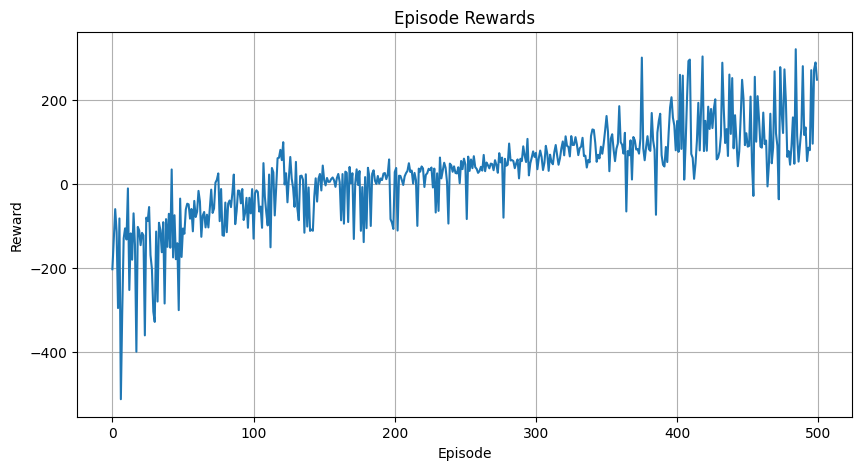

비디오 저장 완료


In [14]:
# 학습 곡선 그리기
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 재생 (가장 최근 저장된 비디오 파일명 확인 필요)
# gymnasium의 RecordVideo는 videos 폴더에 파일을 생성한다.
import glob
import os

# 테스트 플레이 및 비디오 저장
agent.save_video()

# 저장된 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")